# 4.9 電磁波

- 4.9 電磁波
 - 4.9.1 電気振動
 - 4.9.2 変動する電磁界と電磁波の発生
 - 4.9.3 電磁波の種類


## 4.9.0 電気振動 [電流 $I$ 視点]

In [ ]:
#@title おまじない
! pip -qqq install schemdraw
#! pip show schemdraw
! pip -qqq install ziamath

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import schemdraw
import schemdraw.elements as elm

schemdraw.config(font='cmb10')
#elm.style(elm.STYLE_IEC) # IEC/European style
elm.style(elm.STYLE_IEEE) # IEEE style

#schemdraw.config(mathfont='cm')
#import matplotlib.pyplot as plt
#plt.xkcd()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.4/148.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 856.4/856.4 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.5/420.5 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 5.3 MB/s eta 0:00:00


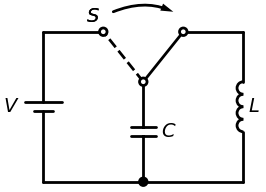

In [ ]:
#@title 電気振動回路
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    # 1. 共通のグラウンド配線
    d += elm.Line().at((-2, 0)).to((2, 0))
    d += elm.Dot().at((0, 0))

    # 2. 左側の枝 (電圧源 V)
    # 1セル、向き反転、左側ラベル（loc='top'）を維持
    d += elm.BatteryCell().at((-2, 0)).to((-2, 3)).reverse().label('$V$', loc='top')
    d += elm.Line().at((-2, 3)).to((-0.8, 3))

    # 修正点：左スイッチ端子（白丸）を描画、ここにはラベルを付けない
    d += elm.Dot(open=True).at((-0.8, 3))

    # (新ステップ) ラベル S を独立して配置する
    # 端子の座標 (-0.8, 3) から、さらに左上にずらした座標 (-1.1, 3.2) を指定。
    d += elm.Label(label='$S$').at((-1.1, 3.2))

    # 3. 右側の枝 (インダクタ L)
    # 右側ラベル（loc='bottom'）を維持
    d += elm.Inductor().at((2, 0)).to((2, 3)).label('$L$', loc='bottom')
    d += elm.Line().at((2, 3)).to((0.8, 3))
    d += elm.Dot(open=True).at((0.8, 3))

    # 4. 中央の枝 (キャパシタ C)
    # 右側ラベル（loc='bottom'）を維持
    d += elm.Capacitor().at((0, 0)).to((0, 2)).label('$C$', loc='bottom')
    d += elm.Dot(open=True).at((0, 2))

    # 5. スイッチの線 (点線・実線) を維持
    d += elm.Line().at((0, 2)).to((-0.8, 3)).linestyle('--')
    d += elm.Line().at((0, 2)).to((0.8, 3))

    # 6. 切り替えを示す曲線矢印 を維持
    d += elm.Arc2(arrow='->', k=0.2).at((-0.6, 3.4)).to((0.6, 3.4))

1. **直流** 電源側 $V$ にスイッチを倒した状態 (電池側に switch on, コイル側は switch off)
 - コンデンサ(capacitor) $C$に蓄えられる電荷 $Q$ は
 \begin{align*}
  Q = C\,V
 \end{align*}
 - コンデンサでの電圧降下($-V_C$)を考慮し、KVL(キルヒホッフの電圧則)を利用すると
 \begin{align*}
  V + (-V_C) = 0
 \end{align*}
 - これらを整理すると
 \begin{align*}
  V_C = V = \dfrac{Q}{C}
 \end{align*}

2. 次に、コイル側にスイッチを倒した状態(コイル側に switch on, 電池側は switch off)
 - コンデンサ(capacitor) $C$に蓄えられる電荷 $Q$ が コイル $L$ に流れ, $V_C$ が電池の役割をする $(+V_C)$
 - コイルでの誘導機電力($-V_L$)を考慮し、KVL(キルヒホッフの電圧則)を利用すると
 \begin{align*}
  (+V_C) + (-V_L) = 0
 \end{align*}
     - 回路に流れる電流を $I$ として、$V_L$ に(微分表現の)レンツの法則を適応すると
 \begin{align*}
  V_L = -L \dfrac{d\,I }{d\,t}
 \end{align*}
 - これらを整理すると
 \begin{align*}
  V_C &= V_L\\[2mm]
  -L \dfrac{d\,I }{d\,t} &= \dfrac{Q}{C}
 \end{align*}

電流の定義$(I=\Delta Q/\Delta t)$が
\begin{align*}
I= \dfrac{d\,Q}{d\,t}
\end{align*}
と表せることから、上記で最後得られた関係式をさらに時間 $t$ で微分すると
\begin{align*}
  -L \dfrac{d^2I }{{dt}^2} = \dfrac{1}{C} \dfrac{d\,Q }{d\,t} &= \dfrac{1}{C} I
\end{align*}
さらに整理すると
\begin{align*}
  \dfrac{d^2I }{{dt}^2} &= - \dfrac{1}{LC} I
\end{align*}


この形は、
1. 電流 $I$ について二階の(常)微分方程式
2. 二回微分すると、次の二つの特徴をもつ
  - $I$ に比例する
  - 負の項が加わる

このような微分方程式の解は、単振動のときと同様に
\begin{align*}
I = A \sin (\omega_0 t) + B \cos(\omega_0 t)
\end{align*}
となる。ここで初期条件 $t=0, I=0$ を考慮すると
\begin{align*}
\require{cancel}
I
&= \cancelto{I_0}{A} \sin (\omega_0 t) + \bcancel{B \cos(\omega_0 t)}\\
&= I_0  \sin (\omega_0 t)
\end{align*}
この解を元の二階の(常)微分方程式に代入すると
\begin{align*}
  \dfrac{d^2I }{{dt}^2}
  &= - I_0 \, \omega_0 ^2 \, \sin \omega_0 t =  - \omega_0 ^2\, I
  = - \dfrac{1}{LC} I
\end{align*}
となり、一般的に $L,C>0$ であることを踏まえると
\begin{align*}
  \omega_0 = \dfrac{1}{\sqrt{LC}}
\end{align*}
となる。ここで
> $\omega_0$ をこの振動回路の **角周波数** と呼ぶ。





また、$\omega_0$ を周期 $T$ と 振動数 $f$ の関係
\begin{align*}
\omega = \dfrac{2\pi}{T} = 2\pi\,\dfrac{1}{T}  = 2\pi\,f
\end{align*}
を利用すると
\begin{align*}
f_0 = \dfrac{\omega_0}{2\pi} =  \dfrac{1}{2 \pi\sqrt{LC}}
\end{align*}
ここで、
> $f_0$ をこの振動回路の **周波数** と呼ぶ。

電荷を蓄えた後の $LC$回路の 電流 $I$は
\begin{align*}
I = I_0 \sin \omega_0 t, \qquad  \omega_0 =\dfrac{1}{\sqrt{LC}}
\end{align*}
で与えられるので、この回路の(電源として働くコンデンサの)電圧 $V$ は
\begin{align*}
V&=  V_C = V_L
= -L \dfrac{d\,I }{d\,t}
= -L \dfrac{d}{d\,t}\left(I_0 \sin \omega_0 t\right)
=- L I_0\, \omega_0 \cos \omega_0 t\\
&= - V_0 \cos \omega_0 t.
\end{align*}
このとき
\begin{align*}
V_0 &= L\, I_0, \omega_0\\[2mm]
I_0 &= \dfrac{V_0}{L \omega_0}
\end{align*}
が成り立つ。

## 4.9.1 電気振動[電荷 $Q$ 視点]

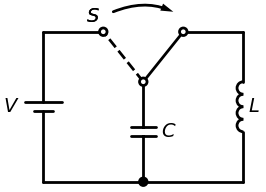

In [ ]:
#@title 電気振動回路
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    # 1. 共通のグラウンド配線
    d += elm.Line().at((-2, 0)).to((2, 0))
    d += elm.Dot().at((0, 0))

    # 2. 左側の枝 (電圧源 V)
    # 1セル、向き反転、左側ラベル（loc='top'）を維持
    d += elm.BatteryCell().at((-2, 0)).to((-2, 3)).reverse().label('$V$', loc='top')
    d += elm.Line().at((-2, 3)).to((-0.8, 3))

    # 修正点：左スイッチ端子（白丸）を描画、ここにはラベルを付けない
    d += elm.Dot(open=True).at((-0.8, 3))

    # (新ステップ) ラベル S を独立して配置する
    # 端子の座標 (-0.8, 3) から、さらに左上にずらした座標 (-1.1, 3.2) を指定。
    d += elm.Label(label='$S$').at((-1.1, 3.2))

    # 3. 右側の枝 (インダクタ L)
    # 右側ラベル（loc='bottom'）を維持
    d += elm.Inductor().at((2, 0)).to((2, 3)).label('$L$', loc='bottom')
    d += elm.Line().at((2, 3)).to((0.8, 3))
    d += elm.Dot(open=True).at((0.8, 3))

    # 4. 中央の枝 (キャパシタ C)
    # 右側ラベル（loc='bottom'）を維持
    d += elm.Capacitor().at((0, 0)).to((0, 2)).label('$C$', loc='bottom')
    d += elm.Dot(open=True).at((0, 2))

    # 5. スイッチの線 (点線・実線) を維持
    d += elm.Line().at((0, 2)).to((-0.8, 3)).linestyle('--')
    d += elm.Line().at((0, 2)).to((0.8, 3))

    # 6. 切り替えを示す曲線矢印 を維持
    d += elm.Arc2(arrow='->', k=0.2).at((-0.6, 3.4)).to((0.6, 3.4))

1. **直流** 電源側 $V$ にスイッチを倒した状態 (電池側に switch on, コイル側は switch off)
 - コンデンサ(capacitor) $C$に蓄えられる電荷 $Q$ は
 \begin{align*}
  Q_0 = C\,V_C
 \end{align*}
 - コンデンサでの電圧降下($-V_C$)を考慮し、KVL(キルヒホッフの電圧則)を利用すると
 \begin{align*}
  V + (-V_C) = 0
 \end{align*}
 - これらを整理すると
 \begin{align*}
  V_C = V = \dfrac{Q_0}{C}
 \end{align*}

2. 次に、コイル側にスイッチを倒した状態(コイル側に switch on, 電池側は switch off)
 - コンデンサ(capacitor) $C$に蓄えられる電荷 $Q$ が コイル $L$ に流れ, $V_C$ が電池の役割をする $(+V_C)$
 - コイルでの誘導起電力($V_L$)を考慮し、KVL(キルヒホッフの電圧則)を利用すると
 \begin{align*}
0 +  (-V_C) + (+V_L) = 0
 \end{align*}
    - 回路に流れる電流を $I$ として、 $V_L$ に(微分表現の)レンツの法則を適応すると
 \begin{align*}
  V_L = -L \dfrac{d\,I }{d\,t}
 \end{align*}
 - 電荷 $Q_0$ から、時間 $t$ に伴って変化するので
 \begin{align*}
 Q=Q(t)
 \end{align*}
 - これらを整理すると
 \begin{align*}
  V_C &= V_L\\[2mm]
  -L \dfrac{d\,I }{d\,t} &= \dfrac{Q}{C}
 \end{align*}

電流の定義$(I=\Delta Q/\Delta t)$が
\begin{align*}
I= \dfrac{d\,Q}{d\,t}
\end{align*}
と表せることから、先程求めた一階の微分方程式
\begin{align*}
  -L \dfrac{d\,I }{d\,t} &= \dfrac{Q}{C}
\end{align*}
へ代入すると
\begin{align*}
  -L \dfrac{d^2\,Q }{d\,t^2} &= \dfrac{Q}{C}\\[2mm]
  \dfrac{d^2\,Q }{d\,t^2} &=  -\dfrac{1}{LC}\, Q,
\end{align*}
$Q$ についての二回の微分方程式が現れる.


この二階の微分方程式の一般解は
\begin{align*}
Q
&= A_1 \sin (\omega_0 t) + A_2 \cos(\omega_0 t)\\
&= A  \sin (\omega_0 t + \delta) ,
\qquad \left(\tan \delta = \frac{A_1}{A_2}, A = \sqrt{{A_1}^2 + {A_2}^2}\right)
\end{align*}
で、この解をもとの微分方程式に代入しすると
\begin{align*}
&- \omega_0^2  A  \sin (\omega_0 t + \delta)
= - \omega_0^2 Q
= -\dfrac{1}{LC}\, Q\\
{\omega_0}^2 &= \dfrac{1}{LC}
\end{align*}
ここで $L,C>0$ なので [p114 (4.80)]
\begin{align*}
{\omega_0} &= \dfrac{1}{\sqrt{LC}}
\end{align*}
ここで
> $\omega_0$ をこの振動回路の **角周波数** と呼ぶ。

これらの微分方程式の解を定めるために、１から２の状態を考えたことを思い出して、  
初期条件を整理すると、
\begin{align*}
t&=0;\\[2mm]
&\begin{cases}
Q(t=0) = Q(0) = Q_0\\
I(t=0) = I(0) = 0
\end{cases}\\[3mm]
&\begin{cases}
Q_0 &= A \sin (\omega_0\, 0 + \delta) = A \sin \delta\\
0 &=\dfrac{d\,Q}{d\,t}\Big|_{t=0}
= \omega_0 A \cos (\omega_0 t + \delta)\Big|_{t=0} = \omega_0 A \cos\delta
\end{cases}\\[3mm]
&\begin{cases}
Q_0 &= A \sin \delta\\
0 &= \omega_0 A \cos\delta
\end{cases}\\[3mm]
&\begin{cases}
Q_0 &= A \\
\delta &= \dfrac{\pi}{2}
\end{cases}
\end{align*}



求める $Q(t), I(t)$ はそれぞれ
\begin{align*}
Q(t) &= Q_0  \sin (\omega_0 t + \dfrac{\pi}{2})  =  Q_0\, \cos \omega_0 t\\[3mm]
I(t) &= \dfrac{d\,Q}{dt} = - \omega_0 Q_0 \sin \omega t\\
&= - \omega_0 (CV) \sin \omega t \\
&= - \dfrac{\omega_0^2 (CV)}{\omega_0} \sin \omega t \\
&= - \dfrac{\frac{1}{LC} (CV)}{\omega_0} \sin \omega t \\
&= - \dfrac{V}{L\omega_0} \sin \omega t
=  \dfrac{V}{L\omega_0} \cos \left( \omega t + \dfrac{\pi}{2}\right)
\end{align*}

この回路の、これより最大の電流値 $I_0$ は
\begin{align*}
I_0 = \omega_0\, Q_0 = \omega_0 C\,V = \omega_0 \left( \dfrac{1}{L\,\omega_0^2}\right) V   =\dfrac{V}{L\omega_0}
\end{align*}
ともとまる.


### 抵抗のない振動回路のエネルギー保存

1. 今考えている回路には抵抗 $R$ が含まれいないとすれば、エネルギーの損失を考える必要がない。
2. 次のように考えると時間変動が起こったとしても、コンデンサーに蓄えられたエネルギーが、コイルに移動することがわかる。
3. ただし実際には、同線にも抵抗があるため、振動回路は減衰していく


$$
\begin{align*}
\dfrac{1}{2} C V_0^2 &= \dfrac{1}{2} C V^2  + \dfrac{1}{2} L I^2\\
&=\dfrac{1}{2} C \left(\dfrac{1}{C} Q_0 \cos\omega t\right){}^2  
+ \dfrac{1}{2} L \left( - \omega_0 Q_0 \sin\omega t \right){}^2
=\dfrac{1}{2}\, \dfrac{Q_0^2}{C}\,\cos{}^2\omega t  
+ \dfrac{1}{2}\, L\, \omega_0^2\, Q_0^2 \sin{}^2\omega t \\
&=\dfrac{1}{2}\, \dfrac{(\frac{I_0}{\omega_0})^2}{C}\,\cos{}^2\omega t  
+ \dfrac{1}{2}\, L\, I_0^2 \sin{}^2\omega t
=\dfrac{1}{2}\, L\, I_0^2\,\cos{}^2\omega t  
+ \dfrac{1}{2}\, L\, I_0^2\,\sin{}^2\omega t\\
&= \dfrac{1}{2}\, L\, I_0^2
\end{align*}
$$

In [ ]:
#@title 電気振動のシミュレーション
%%html
<iframe width="560" height="315" src="https://www.youtube-nocookie.com/embed/nsVBQHWvnPM?si=dL1X8cSseqP9rpYU" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

## 4.9.2 変動する電磁界と電磁波の発生

電界と磁界の相補関係

![](https://scrapbox.io/files/6699dd5ac5c6d5001e52598f.png)

簡易電磁場発生装置

![](https://scrapbox.io/files/6699dddec88ab0001df41182.png)

![](https://upload.wikimedia.org/wikipedia/commons/4/4c/Electromagneticwave3D.gif)

この考えを発展させて、４つのマクスウェル方程式を真空中で解くと、
- 真空の誘電率 $\varepsilon_0$
- 真空の透磁率 $\mu_0$

を用いて、電磁波の一蹴である光速 $c$ が次のように理論的に求められる。
\begin{align*}
c  = \dfrac{1}{\sqrt{\varepsilon_0 \mu_0}}
\end{align*}



電磁波である光は(横浪の)波動性を満たし
\begin{align*}
c = \lambda\, f  =\dfrac{\lambda}{T}
\end{align*}
を満たす

![](https://upload.wikimedia.org/wikipedia/commons/thumb/1/14/EM_spectrum_updated.svg/1024px-EM_spectrum_updated.svg.png)